In [12]:
import pandas as pd
import joblib
import os

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report

In [13]:
X_train = pd.read_csv('../data/X_train.csv')
X_test  = pd.read_csv('../data/X_test.csv')
y_train = pd.read_csv('../data/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/y_test.csv').squeeze()

print('X_train shape:', X_train.shape)
print('X_test shape: ', X_test.shape)
print()
print('y_train class distribution:')
print(y_train.value_counts())
print()
print('y_test class distribution:')
print(y_test.value_counts())

X_train shape: (1972, 10)
X_test shape:  (294, 10)

y_train class distribution:
Attrition
0    986
1    986
Name: count, dtype: int64

y_test class distribution:
Attrition
0    247
1     47
Name: count, dtype: int64


In [14]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(f'{name}: training done')

Logistic Regression: training done
Decision Tree: training done
Random Forest: training done


In [15]:
results = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print(f'================================================')
    print(f'  {name}')
    print(f'================================================')
    print(f'  Accuracy: {acc:.4f}')
    print()
    print(classification_report(y_test, y_pred, target_names=['Stayed (0)', 'Left (1)']))


  Logistic Regression
  Accuracy: 0.6769

              precision    recall  f1-score   support

  Stayed (0)       0.92      0.67      0.78       247
    Left (1)       0.29      0.70      0.41        47

    accuracy                           0.68       294
   macro avg       0.61      0.69      0.59       294
weighted avg       0.82      0.68      0.72       294

  Decision Tree
  Accuracy: 0.7585

              precision    recall  f1-score   support

  Stayed (0)       0.89      0.81      0.85       247
    Left (1)       0.33      0.49      0.39        47

    accuracy                           0.76       294
   macro avg       0.61      0.65      0.62       294
weighted avg       0.80      0.76      0.78       294

  Random Forest
  Accuracy: 0.7891

              precision    recall  f1-score   support

  Stayed (0)       0.87      0.87      0.87       247
    Left (1)       0.34      0.34      0.34        47

    accuracy                           0.79       294
   macro avg  

In [19]:
print('Model Accuracy Comparison')
print('-' * 35)

for name, acc in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f'  {name:<25} {acc:.4f}')

best_model_name = max(results, key=results.get)
print()
print(f'Best model: {best_model_name} (accuracy = {results[best_model_name]:.4f})')
best_model = models[best_model_name]

Model Accuracy Comparison
-----------------------------------
  Random Forest             0.7891
  Decision Tree             0.7585
  Logistic Regression       0.6769

Best model: Random Forest (accuracy = 0.7891)


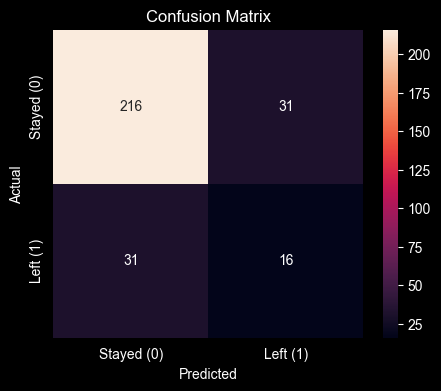

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

best_model = models[best_model_name]

y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Stayed (0)', 'Left (1)'],
            yticklabels=['Stayed (0)', 'Left (1)'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

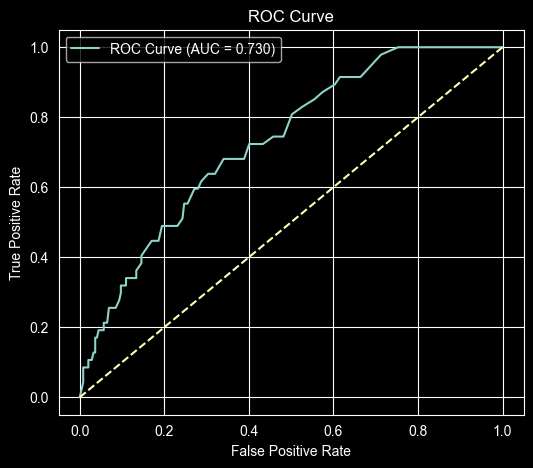

ROC-AUC Score: 0.7296924799724351


In [22]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = best_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

print("ROC-AUC Score:", roc_auc)

In [34]:
importances = best_model.feature_importances_
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(feature_importance.head(10))

                        Feature  Importance
6                           Age    0.155375
5                 MonthlyIncome    0.150382
8          YearsWithCurrManager    0.139905
2             TotalWorkingYears    0.123356
4            YearsInCurrentRole    0.119476
3                      JobLevel    0.107141
9              StockOptionLevel    0.097376
0                  OverTime_Yes    0.073809
1          MaritalStatus_Single    0.023230
7  JobRole_Sales Representative    0.009950


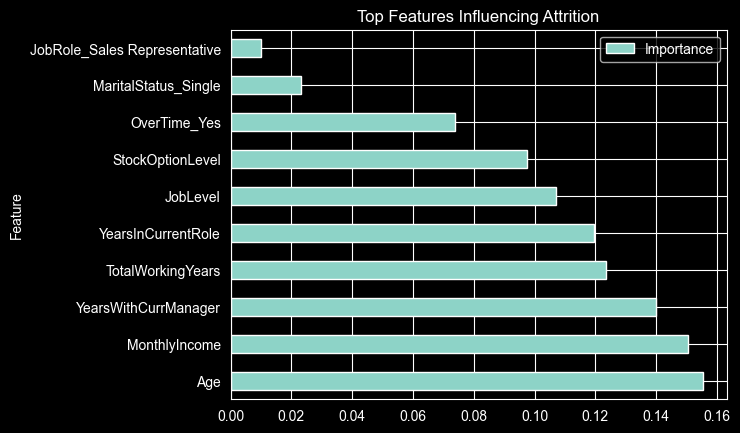

In [42]:
import matplotlib.pyplot as plt

feature_importance.head(10).plot(
    x="Feature",
    y="Importance",
    kind="barh"
)

plt.title("Top Features Influencing Attrition")
plt.show()

In [7]:
os.makedirs('../models', exist_ok=True)

best_model = models[best_model_name]
joblib.dump(best_model, '../models/employee_attrition_model.pkl')

print(f'Saved: ../models/employee_attrition_model.pkl')
print(f'Model: {best_model_name}')

Saved: ../models/employee_attrition_model.pkl
Model: Random Forest
